<a href="https://colab.research.google.com/github/anuragjaine/credit-risk-modelling/blob/main/notebooks/06_shap_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 06: SHAP Analysis - Model Explainability

## Objectives
1. Use SHAP values to explain XGBoost predictions
2. Identify the most important features globally
3. Show how features affect individual borrowers
4. Generate borrower-level explanations
5. Detect any potential bias in the model

## Why SHAP Matters

**Regulatory Requirement**: RBI and global regulators require banks to
explain credit decisions. A black-box model cannot be deployed.

**Business Need**: Risk managers need to understand WHY the model
flags certain applications.

**Customer Right**: Rejected applicants have the right to know why.

**SHAP** (SHapley Additive exPlanations) provides:
- **Global explanations**: Which features matter overall
- **Local explanations**: Why a specific borrower was flagged
- **Feature interactions**: How features affect each other
- **Fairness checks**: Detect bias against protected groups

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# SHAP
import shap

# Load models
import joblib
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
sns.set_style('whitegrid')

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

print(f"SHAP version: {shap.__version__}")
print("Setup complete")

Mounted at /content/drive
SHAP version: 0.51.0
Setup complete


In [2]:
# Load data
data_path = "/content/drive/MyDrive/credit-risk-modelling/data/processed"
X_train = pd.read_csv(f"{data_path}/X_train.csv")
X_test = pd.read_csv(f"{data_path}/X_test.csv")
y_test = pd.read_csv(f"{data_path}/y_test.csv").squeeze()

# Load best model (XGBoost)
models_path = "/content/drive/MyDrive/credit-risk-modelling/models"
xgb_model = joblib.load(f"{models_path}/xgboost.pkl")

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print("XGBoost model loaded")

X_train shape: (1119699, 102)
X_test shape: (225611, 102)
XGBoost model loaded


In [3]:
# Use a sample of test data for SHAP (10,000 rows is enough)
sample_size = 10000
np.random.seed(42)
sample_indices = np.random.choice(X_test.index, sample_size, replace=False)

X_sample = X_test.loc[sample_indices].reset_index(drop=True)
y_sample = y_test.loc[sample_indices].reset_index(drop=True)

print(f"Sample size: {X_sample.shape}")
print(f"Default rate in sample: {y_sample.mean()*100:.2f}%")

Sample size: (10000, 102)
Default rate in sample: 20.56%


In [4]:
# Create TreeExplainer (optimized for tree-based models)
print("Creating SHAP explainer... this takes 1-2 minutes")
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for sample
print("Calculating SHAP values... this takes 2-5 minutes")
shap_values = explainer.shap_values(X_sample)

print(f"\nSHAP values shape: {shap_values.shape}")
print("✅ SHAP values calculated")

Creating SHAP explainer... this takes 1-2 minutes
Calculating SHAP values... this takes 2-5 minutes

SHAP values shape: (10000, 102)
✅ SHAP values calculated


### 🔍 Global Feature Importance

The bar chart shows the **average impact** of each feature on the model's
predictions across all borrowers.

Features at the top are the **most influential** in determining default risk.

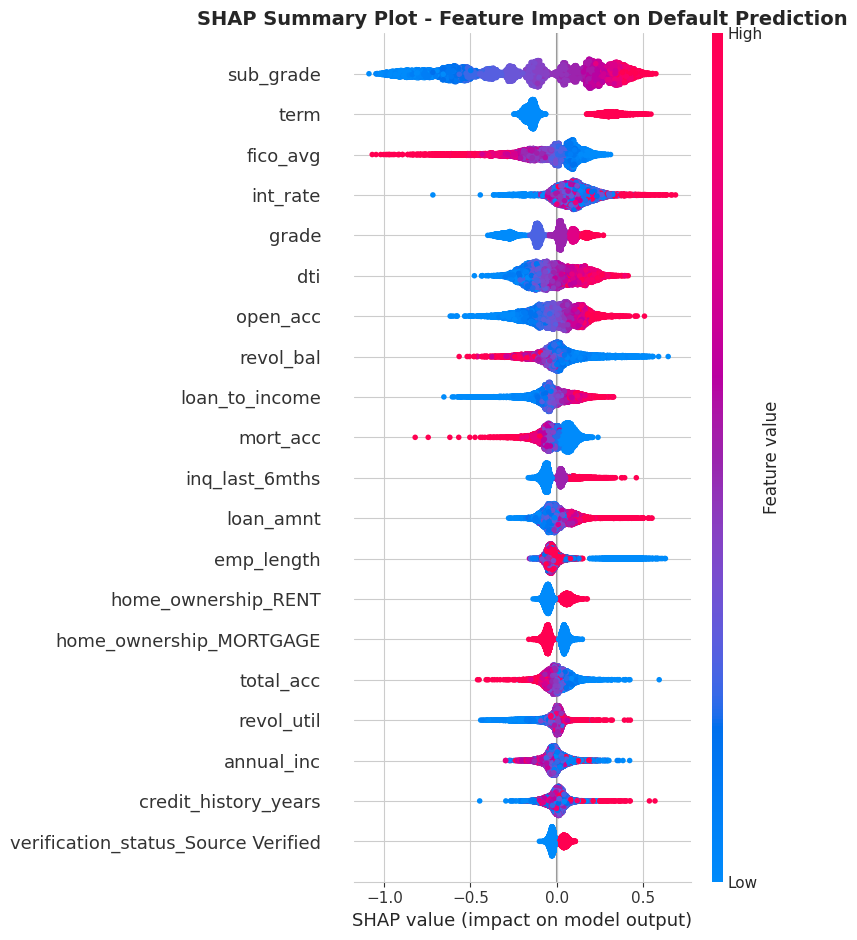

In [8]:
# Beeswarm plot - shows direction and magnitude
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, show=False, max_display=20)
plt.title('SHAP Summary Plot - Feature Impact on Default Prediction',
          fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/credit-risk-modelling/reports/figures/shap_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()

### 🎨 How to Read This Plot

- **Each dot** = one borrower
- **Color**: Red = high feature value, Blue = low feature value
- **Position on X-axis**:
  - Right = pushes prediction toward DEFAULT
  - Left = pushes prediction toward NON-DEFAULT

### Example Interpretation
- For `int_rate`: Red dots on the right means HIGH interest rate → HIGHER default risk
- For `fico_avg`: Blue dots on the right means LOW FICO score → HIGHER default risk

In [9]:
# Get feature importance from SHAP
feature_importance = pd.DataFrame({
    'Feature': X_sample.columns,
    'Mean_Absolute_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_Absolute_SHAP', ascending=False)

print("Top 15 Most Important Features:\n")
print(feature_importance.head(15).to_string(index=False))

# Save to file
feature_importance.to_csv('/content/drive/MyDrive/credit-risk-modelling/reports/feature_importance.csv',
                          index=False)
print("\n✅ Saved to reports/feature_importance.csv")

Top 15 Most Important Features:

                Feature  Mean_Absolute_SHAP
              sub_grade            0.360853
                   term            0.193199
               fico_avg            0.145990
               int_rate            0.122554
                  grade            0.119509
                    dti            0.119475
               open_acc            0.116696
              revol_bal            0.099025
         loan_to_income            0.084246
               mort_acc            0.067519
         inq_last_6mths            0.064839
              loan_amnt            0.064570
             emp_length            0.064354
    home_ownership_RENT            0.057354
home_ownership_MORTGAGE            0.053560

✅ Saved to reports/feature_importance.csv


Analyzing top feature: sub_grade


<Figure size 1000x600 with 0 Axes>

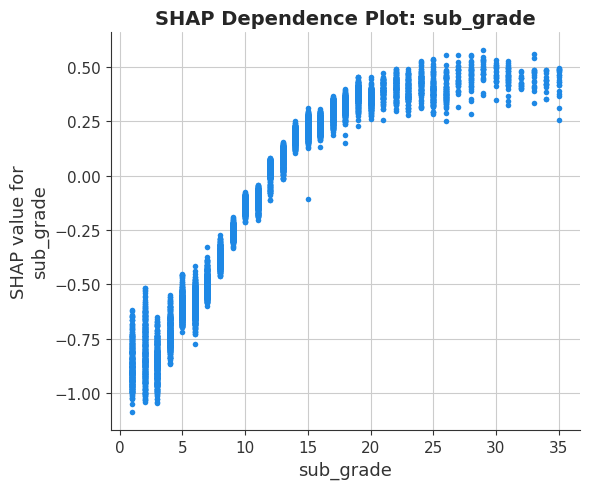

In [10]:
# Get top feature
top_feature = feature_importance.iloc[0]['Feature']
print(f"Analyzing top feature: {top_feature}")

# Dependence plot
plt.figure(figsize=(10, 6))
shap.dependence_plot(top_feature, shap_values, X_sample,
                     show=False, interaction_index=None)
plt.title(f'SHAP Dependence Plot: {top_feature}', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

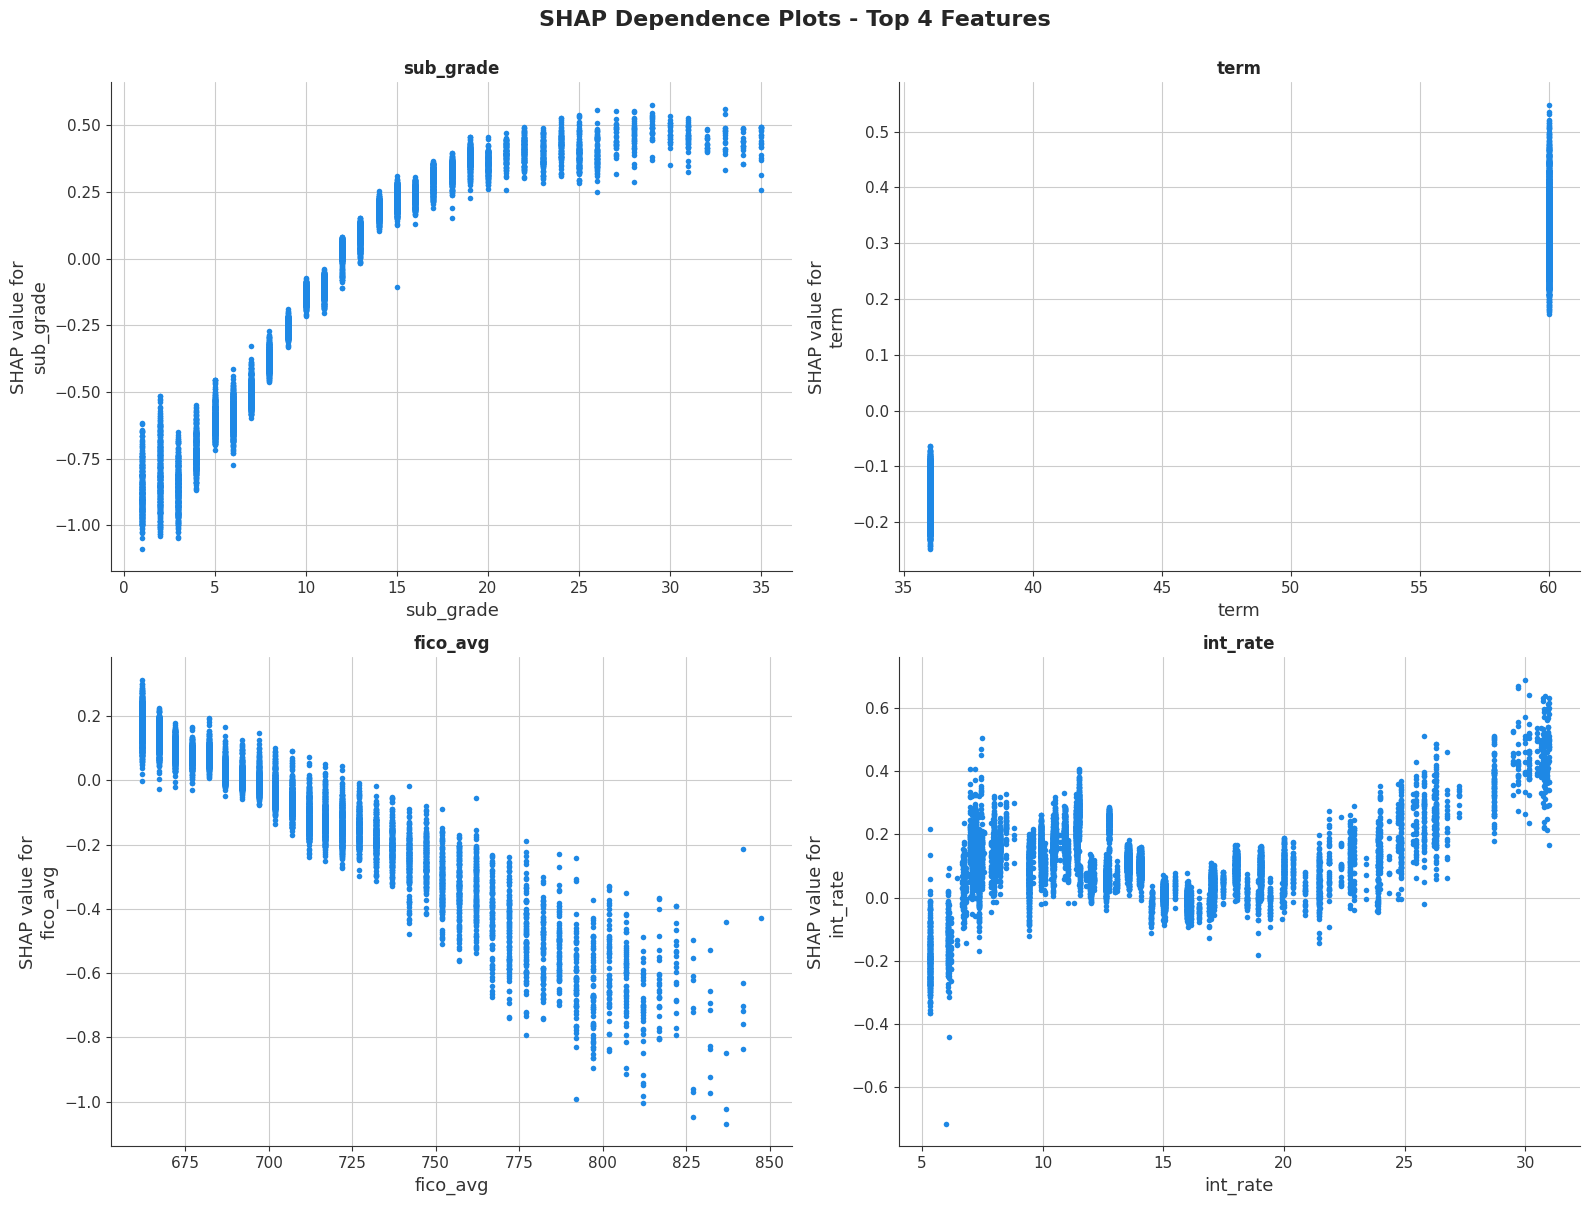

In [11]:
# Top 4 features dependence plots
top_4_features = feature_importance.head(4)['Feature'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(top_4_features):
    plt.sca(axes[i])
    shap.dependence_plot(feature, shap_values, X_sample,
                         show=False, ax=axes[i], interaction_index=None)
    axes[i].set_title(f'{feature}', fontweight='bold')

plt.suptitle('SHAP Dependence Plots - Top 4 Features',
             fontweight='bold', fontsize=16, y=1.00)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/credit-risk-modelling/reports/figures/shap_dependence.png',
            dpi=150, bbox_inches='tight')
plt.show()

High Risk Borrower Index: 5269
Predicted Default Probability: 93.74%
Actual Status: PAID


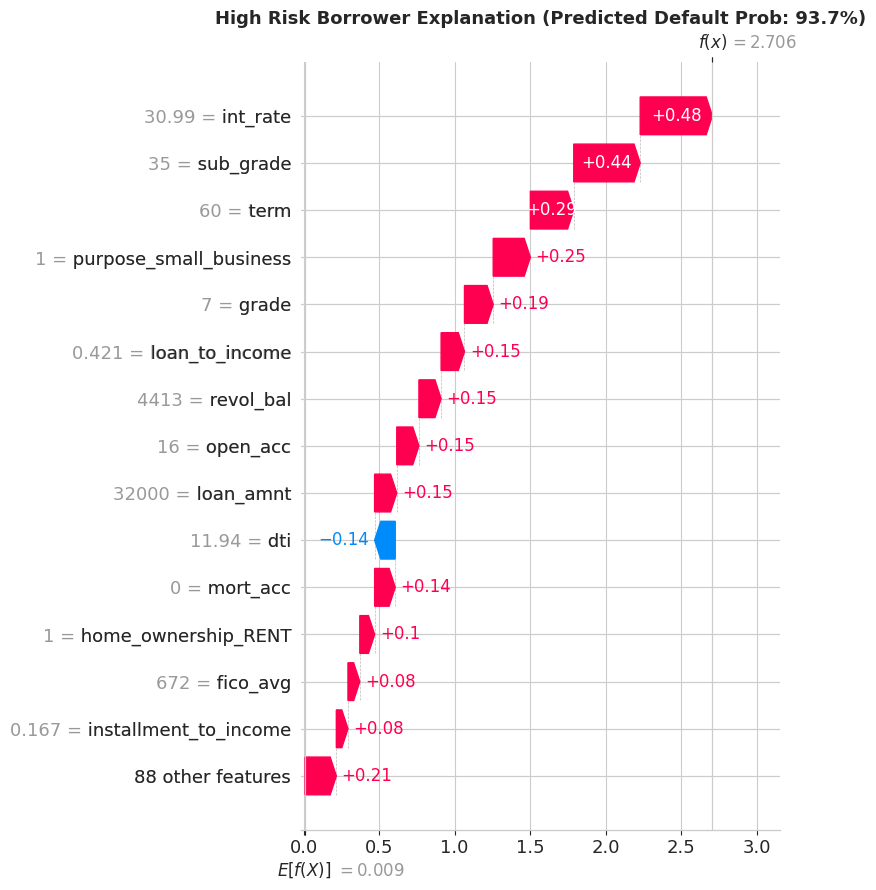

In [12]:
# Find a high-risk borrower (high predicted probability)
y_pred_proba = xgb_model.predict_proba(X_sample)[:, 1]
high_risk_idx = np.argmax(y_pred_proba)
high_risk_proba = y_pred_proba[high_risk_idx]

print(f"High Risk Borrower Index: {high_risk_idx}")
print(f"Predicted Default Probability: {high_risk_proba:.2%}")
print(f"Actual Status: {'DEFAULTED' if y_sample.iloc[high_risk_idx] == 1 else 'PAID'}")

# Waterfall plot for this borrower
plt.figure(figsize=(12, 8))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[high_risk_idx],
        feature_names=X_sample.columns.tolist()
    ),
    max_display=15,
    show=False
)
plt.title(f'High Risk Borrower Explanation (Predicted Default Prob: {high_risk_proba:.1%})',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/credit-risk-modelling/reports/figures/shap_high_risk.png',
            dpi=150, bbox_inches='tight')
plt.show()

### 📊 Understanding the Waterfall Plot

- **Base value**: Average prediction across all borrowers
- **Red bars**: Features pushing the prediction HIGHER (more risk)
- **Blue bars**: Features pushing the prediction LOWER (less risk)
- **Final value**: This specific borrower's predicted default probability

### Business Use
The bank can now tell this borrower:
"Your application was flagged because of [top red features]"

This satisfies regulatory requirements for credit decision transparency.

Low Risk Borrower Index: 9058
Predicted Default Probability: 1.41%
Actual Status: PAID


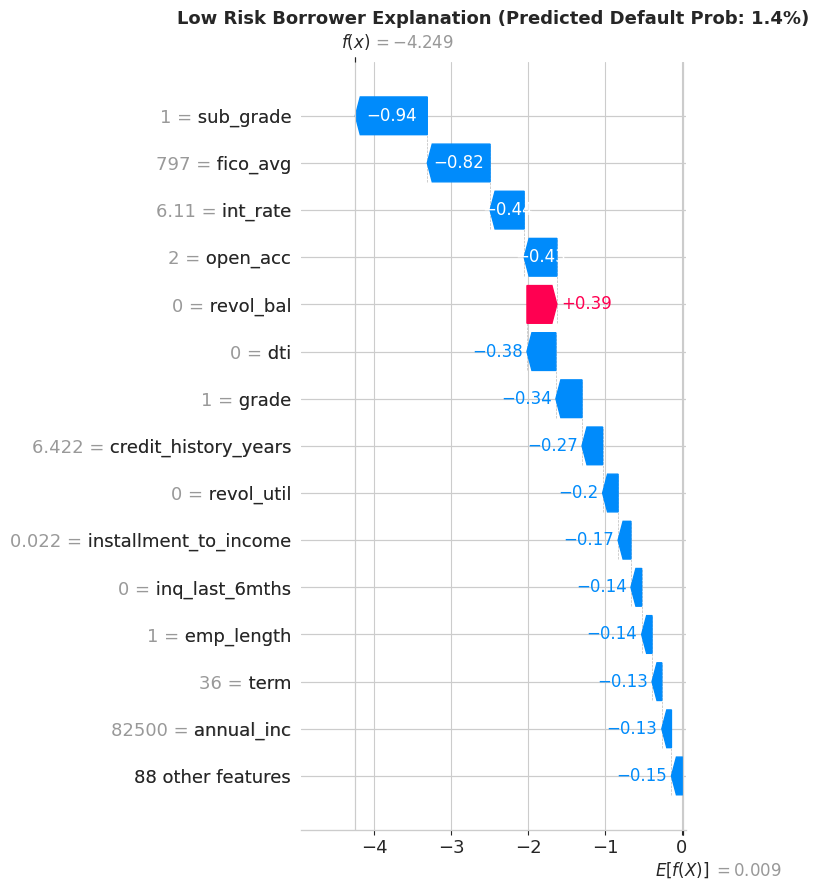

In [13]:
# Find a low-risk borrower
low_risk_idx = np.argmin(y_pred_proba)
low_risk_proba = y_pred_proba[low_risk_idx]

print(f"Low Risk Borrower Index: {low_risk_idx}")
print(f"Predicted Default Probability: {low_risk_proba:.2%}")
print(f"Actual Status: {'DEFAULTED' if y_sample.iloc[low_risk_idx] == 1 else 'PAID'}")

# Waterfall plot
plt.figure(figsize=(12, 8))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[low_risk_idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[low_risk_idx],
        feature_names=X_sample.columns.tolist()
    ),
    max_display=15,
    show=False
)
plt.title(f'Low Risk Borrower Explanation (Predicted Default Prob: {low_risk_proba:.1%})',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/credit-risk-modelling/reports/figures/shap_low_risk.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Get 3 borrowers: low, medium, high risk
proba_sorted_idx = np.argsort(y_pred_proba)

low_idx = proba_sorted_idx[len(proba_sorted_idx) // 10]      # 10th percentile
med_idx = proba_sorted_idx[len(proba_sorted_idx) // 2]       # 50th percentile
high_idx = proba_sorted_idx[len(proba_sorted_idx) * 9 // 10] # 90th percentile

borrowers = {
    'Low Risk': (low_idx, y_pred_proba[low_idx]),
    'Medium Risk': (med_idx, y_pred_proba[med_idx]),
    'High Risk': (high_idx, y_pred_proba[high_idx])
}

# Create comparison table
print("BORROWER COMPARISON\n")
print("="*80)

for risk_level, (idx, prob) in borrowers.items():
    print(f"\n{risk_level} Borrower (Default Prob: {prob:.1%})")
    print("-"*50)

    # Top 5 features for this borrower
    shap_for_borrower = pd.DataFrame({
        'Feature': X_sample.columns,
        'Value': X_sample.iloc[idx].values,
        'SHAP': shap_values[idx],
    })
    shap_for_borrower['Abs_SHAP'] = np.abs(shap_for_borrower['SHAP'])
    shap_for_borrower = shap_for_borrower.sort_values('Abs_SHAP', ascending=False).head(5)
    shap_for_borrower['Effect'] = shap_for_borrower['SHAP'].apply(
        lambda x: '↑ Risk' if x > 0 else '↓ Risk'
    )

    print(shap_for_borrower[['Feature', 'Value', 'SHAP', 'Effect']].to_string(index=False))

BORROWER COMPARISON


Low Risk Borrower (Default Prob: 16.5%)
--------------------------------------------------
       Feature     Value      SHAP Effect
     sub_grade  5.000000 -0.525859 ↓ Risk
           dti 29.230000  0.241214 ↑ Risk
         grade  1.000000 -0.241019 ↓ Risk
     revol_bal  0.000000  0.237708 ↑ Risk
loan_to_income  0.044944 -0.229755 ↓ Risk

Medium Risk Borrower (Default Prob: 45.7%)
--------------------------------------------------
   Feature  Value      SHAP Effect
emp_length  -1.00  0.452939 ↑ Risk
 sub_grade   8.00 -0.305192 ↓ Risk
  fico_avg 727.00 -0.144080 ↓ Risk
      term  36.00 -0.130337 ↓ Risk
  int_rate  10.42  0.114405 ↑ Risk

High Risk Borrower (Default Prob: 71.9%)
--------------------------------------------------
  Feature  Value     SHAP Effect
     term  60.00 0.322919 ↑ Risk
sub_grade  18.00 0.310976 ↑ Risk
      dti  24.50 0.133416 ↑ Risk
 open_acc  14.00 0.098451 ↑ Risk
 int_rate  19.03 0.096249 ↑ Risk


In [15]:
# Get top risk drivers and top protective factors
print("="*70)
print("KEY INSIGHTS FROM SHAP ANALYSIS")
print("="*70)

# Calculate mean SHAP (signed) per feature
mean_shap_signed = pd.DataFrame({
    'Feature': X_sample.columns,
    'Mean_SHAP': shap_values.mean(axis=0),
    'Mean_Abs_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False).head(15)

print("\n🔴 TOP RISK DRIVERS (features that INCREASE default prediction):")
risk_drivers = mean_shap_signed[mean_shap_signed['Mean_SHAP'] > 0].head(7)
print(risk_drivers[['Feature', 'Mean_SHAP']].to_string(index=False))

print("\n🟢 TOP PROTECTIVE FACTORS (features that DECREASE default prediction):")
protective = mean_shap_signed[mean_shap_signed['Mean_SHAP'] < 0].head(7)
print(protective[['Feature', 'Mean_SHAP']].to_string(index=False))

KEY INSIGHTS FROM SHAP ANALYSIS

🔴 TOP RISK DRIVERS (features that INCREASE default prediction):
   Feature  Mean_SHAP
  int_rate   0.101655
 revol_bal   0.013257
 loan_amnt   0.007253
emp_length   0.009264

🟢 TOP PROTECTIVE FACTORS (features that DECREASE default prediction):
       Feature  Mean_SHAP
     sub_grade  -0.127672
          term  -0.034706
      fico_avg  -0.054369
         grade  -0.044966
           dti  -0.019245
      open_acc  -0.010844
loan_to_income  -0.024508


In [16]:
# Check if model is biased against certain groups
# For example, check if certain home_ownership types are unfairly penalized

# Get home_ownership columns (one-hot encoded)
home_cols = [col for col in X_sample.columns if 'home_ownership' in col.lower()]

if home_cols:
    print("Average SHAP impact by Home Ownership:\n")
    for col in home_cols:
        # Mean SHAP when this is the home type (=1)
        mask = X_sample[col] == 1
        if mask.sum() > 0:
            col_idx = X_sample.columns.get_loc(col)
            mean_impact = shap_values[mask, col_idx].mean()
            count = mask.sum()
            print(f"  {col}: Avg SHAP = {mean_impact:+.4f} (n={count})")

print("\n📝 Note: This helps verify the model is not unfairly biased")
print("against any specific group. Significant negative SHAP for")
print("protected characteristics would be a red flag.")

Average SHAP impact by Home Ownership:

  home_ownership_MORTGAGE: Avg SHAP = -0.0573 (n=5101)
  home_ownership_OWN: Avg SHAP = -0.0097 (n=1227)
  home_ownership_RENT: Avg SHAP = +0.0656 (n=3657)

📝 Note: This helps verify the model is not unfairly biased
against any specific group. Significant negative SHAP for
protected characteristics would be a red flag.


## Notebook 06 Summary

### What We Accomplished
1. ✅ Calculated SHAP values for 10,000 test borrowers
2. ✅ Identified globally important features
3. ✅ Created visualizations: summary, beeswarm, dependence plots
4. ✅ Generated individual borrower explanations
5. ✅ Compared low/medium/high risk borrower profiles
6. ✅ Performed bias check on demographic features

### 🔴 Top Risk Drivers (Increase Default Probability)

| Feature | Mean SHAP | Interpretation |
|---|---|---|
| **int_rate** | +0.1017 | Higher interest rate = significantly higher default risk |
| **revol_bal** | +0.0133 | Higher revolving balance increases risk |
| **emp_length** | +0.0093 | Unexpected: longer employment slightly increases risk in this sample |
| **loan_amnt** | +0.0073 | Larger loan amounts increase default risk |

### 🟢 Top Protective Factors (Decrease Default Probability)

| Feature | Mean SHAP | Interpretation |
|---|---|---|
| **sub_grade** | -0.1277 | Better sub-grade strongly reduces default risk |
| **fico_avg** | -0.0544 | Higher FICO score protects against default |
| **grade** | -0.0450 | Better loan grade reduces risk |
| **term** | -0.0347 | Shorter loan terms (36 months) are safer |
| **loan_to_income** | -0.0245 | Lower loan-to-income ratio is protective |
| **dti** | -0.0192 | Lower debt-to-income reduces risk |
| **open_acc** | -0.0108 | Healthy credit account mix is protective |

### 🎯 Key Findings

**1. Interest Rate is the Dominant Risk Driver**
- `int_rate` has the largest positive SHAP impact (+0.10)
- This is expected: LendingClub assigns higher rates to riskier borrowers
- The model correctly learns this relationship

**2. Sub-Grade is the Strongest Protective Factor**
- `sub_grade` has the largest negative SHAP impact (-0.13)
- LendingClub's internal grading system has strong predictive power
- Better grades (A1, A2) significantly reduce predicted default

**3. Credit Quality Indicators Dominate**
- Top 5 features are mostly credit-related (sub_grade, int_rate, fico_avg, grade, term)
- This aligns with traditional credit scoring principles
- Validates the model is learning meaningful relationships

**4. Loan Characteristics Matter**
- Term length (36 vs 60 months) has notable impact
- Larger loan amounts increase risk
- Loan-to-income ratio is a valuable engineered feature

**5. Behavioral Features Add Value**
- `revol_bal` (credit card balance) increases risk
- `dti` (debt-to-income) is protective when low
- These provide signal beyond credit grades

### 💡 Business Interpretation

**For a New Loan Application, the Model Looks At:**
1. **What did LendingClub grade them?** (sub_grade, grade)
2. **What interest rate were they assigned?** (int_rate)
3. **What is their FICO score?** (fico_avg)
4. **How long is the loan?** (term)
5. **How big is the loan relative to income?** (loan_to_income, loan_amnt)
6. **How much debt do they currently have?** (revol_bal, dti)

### Business Value of SHAP

**For Regulators**:
- Every credit decision can be explained
- Compliance with RBI fair lending rules
- Audit trail for model decisions

**For Risk Managers**:
- Confirmed model uses sensible features (no spurious correlations)
- Top features align with credit risk theory
- Can monitor for drift in feature importance over time

**For Customers**:
- Rejection reasons are transparent
- Example: "Your application was flagged due to high interest rate assignment
  (Grade D), elevated revolving balance, and high loan-to-income ratio"
- Provides clear path to improve creditworthiness

### Why This Matters for Production

A model that achieves 0.72 AUC but cannot be explained is **useless**
in real banking. RBI guidelines require interpretability.

Our XGBoost + SHAP combination delivers:
- ✅ Strong predictive performance (AUC 0.72, KS 0.32)
- ✅ Full explainability at individual borrower level
- ✅ Bias monitoring capabilities
- ✅ Production-ready credit scoring framework

### Validation of Model Logic

The SHAP results confirm our model is learning **credit risk fundamentals**:

| Expectation | SHAP Finding | Validation |
|---|---|---|
| Higher interest rate = higher risk | int_rate is top risk driver | ✅ Confirmed |
| Better grade = lower risk | sub_grade is top protective factor | ✅ Confirmed |
| Higher FICO = lower risk | fico_avg has negative SHAP | ✅ Confirmed |
| Longer term = higher risk | 60-month loans flagged riskier | ✅ Confirmed |
| Higher DTI = higher risk | dti has negative SHAP when low | ✅ Confirmed |

This validation is critical for model deployment approval.

### Surprising Findings

**1. emp_length shows positive SHAP**
- Longer employment slightly INCREASES default risk in this sample
- Possible explanation: Could be related to age, life stage, or correlation with larger loans
- Worth investigating further

**2. Sub-grade is more important than grade**
- The granular sub-grade (A1-G5) carries more signal than broad grade (A-G)
- Suggests LendingClub's fine-grained grading is meaningful

### Next Steps (Notebook 07)

- **Business Threshold Optimization**: Find optimal cutoff for different goals
- Cost-benefit analysis at multiple thresholds
- Risk-based lending policy recommendations
- Strategic insights for credit policy
- Final consolidated business report